In [1]:
# Resstock to Urbanopt building characterisitics disaggregation 
# Prediciting building characterisitcs using ResStock data 

"""
Created on May 04 12:00:00 2024

@authors: Rawad El Kontar

reference: https://docs.nrel.gov/docs/fy24osti/90883.pdf 

citation: 
El Kontar, Rawad, et al. 
An Open-Source Framework for Characterizing Urban Energy Models: 
Integrating Top-Down and Bottom-Up Methods to Predict Residential Buildings Characteristics.
No. NREL/CP-5500-90883. National Renewable Energy Laboratory (NREL), Golden, CO (United States), 2024.

"""

'\nCreated on May 04 12:00:00 2024\n\n@authors: rawadelkontar\n'

In [1]:
import os
import json
import random
import numpy as np
from datetime import datetime
import time
from collections import defaultdict
import pandas as pd
import gzip
import csv
import matplotlib.pyplot as plt
import pickle
from sklearn.preprocessing import normalize
from collections import defaultdict
import math
import pandas as pd

df = pd.read_csv('MD_baseline_metadata_and_annual_results-3.csv')

/var/folders/5x/sfcdfls15jbf4r0g6vcnnncrqq5sjn/T/ipykernel_65900/3689598392.py:21: DtypeWarning: Columns (131) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('MD_baseline_metadata_and_annual_results-3.csv')


In [7]:
# Extract input and output variables
#input_columns = [col for col in df.columns if col.startswith('in.')]
output_variable = 'out.site_energy.total.energy_consumption.kwh'
input_columns = [
    
'bldg_id', #
  
'in.sqft',
    
 'in.area_median_income',#
    
 'in.battery',
 'in.bedrooms',
 'in.ceiling_fan',
 'in.clothes_dryer',
 'in.clothes_dryer_usage_level',
 'in.clothes_washer',
 'in.clothes_washer_presence',
 'in.clothes_washer_usage_level',
 'in.cooking_range',
 'in.cooking_range_usage_level',
 'in.cooling_setpoint',
 'in.cooling_setpoint_has_offset',
 'in.cooling_setpoint_offset_magnitude',
 'in.cooling_setpoint_offset_period',
 'in.corridor',
 'in.dishwasher',
 'in.dishwasher_usage_level',
 'in.door_area',
 'in.duct_leakage_and_insulation',
 'in.duct_location',

 'in.federal_poverty_level',#
                 
 'in.geometry_attic_type',
    
 'in.geometry_building_horizontal_location_mf',#
 'in.geometry_building_horizontal_location_sfa',#
 'in.geometry_building_level_mf',#
 'in.geometry_building_number_units_mf',#
 'in.geometry_building_number_units_sfa',#


 'in.geometry_building_type_recs',
 'in.geometry_floor_area', #
 'in.geometry_floor_area_bin',
 'in.geometry_foundation_type',
 'in.geometry_garage',
 'in.geometry_stories',
 'in.geometry_stories_low_rise',
 'in.geometry_story_bin',
 'in.geometry_wall_exterior_finish',
 'in.geometry_wall_type',
    
 'in.has_pv',
 'in.heating_fuel',
 'in.heating_setpoint',
 'in.heating_setpoint_has_offset',
 'in.heating_setpoint_offset_magnitude',
 'in.heating_setpoint_offset_period',
 'in.holiday_lighting',
 'in.hot_water_distribution',
 'in.hot_water_fixtures',
                 
 'in.household_has_tribal_persons',#
                 
 'in.hvac_cooling_efficiency',
 'in.hvac_cooling_partial_space_conditioning',
 'in.hvac_cooling_type',
 'in.hvac_has_ducts',
 'in.hvac_has_shared_system',
 'in.hvac_has_zonal_electric_heating',
 'in.hvac_heating_efficiency',
 'in.hvac_heating_type',
 'in.hvac_heating_type_and_fuel',

 'in.hvac_shared_efficiencies',#
    
 'in.income_recs_2020',
    
 'in.infiltration',
 'in.insulation_ceiling',
 'in.insulation_floor',
 'in.insulation_foundation_wall',
 'in.insulation_rim_joist',
 'in.insulation_roof',
 'in.insulation_slab',
 'in.insulation_wall',
 'in.interior_shading',

 'in.lighting',
 'in.lighting_interior_use',
 'in.lighting_other_use',

 'in.mechanical_ventilation',
 'in.misc_extra_refrigerator',
 'in.misc_freezer',
 'in.misc_gas_fireplace',
 'in.misc_gas_grill',
 'in.misc_gas_lighting',
 'in.misc_hot_tub_spa',
 'in.misc_pool',
 'in.misc_pool_heater',#
 'in.misc_pool_pump',#
 'in.misc_well_pump',#
 'in.natural_ventilation',
 'in.neighbors',
 'in.occupants',
 'in.orientation',
 'in.overhangs',
 'in.plug_load_diversity',
 'in.plug_loads',

 'in.pv_orientation',
 'in.pv_system_size',
 'in.radiant_barrier',

 'in.refrigerator',
 'in.refrigerator_usage_level',
 'in.roof_material',

 'in.solar_hot_water',

 'in.tenure',

 'in.usage_level',

 'in.vacancy_status',
 'in.vintage', #
 'in.vintage_acs',
 'in.water_heater_efficiency',
 'in.water_heater_fuel',
 'in.water_heater_in_unit',

 'in.window_areas',
 'in.windows',
 'in.representative_income'#
                ]

# Create the new DataFrame with input and output variables
new_df = df[input_columns + [output_variable]]

In [ ]:
#new_df.head()
#new_df.to_csv('cleandata_for_importance_sampling.csv', index = False)

## SENSITIVITY ANALYSIS USING RANDOM FOREST 

In [12]:
abbreviations = {
        'in.sqft': 'sqft',
        'in.area_median_income': 'area_inc',
        'in.battery': 'batt',
        'in.bedrooms': 'bedrms',
        'in.ceiling_fan': 'ceil_fan',
        'in.clothes_dryer': 'dryer',
        'in.clothes_dryer_usage_level': 'dryer_lvl',
        'in.clothes_washer': 'washer',
        'in.clothes_washer_presence': 'washer_prsnc',
        'in.clothes_washer_usage_level': 'washer_lvl',
        'in.cooking_range': 'cook_rng',
        'in.cooking_range_usage_level': 'cook_rng_lvl',
        'in.cooling_setpoint': 'cool_sp',
        'in.cooling_setpoint_has_offset': 'cool_sp_os',
        'in.cooling_setpoint_offset_magnitude': 'cool_sp_os_mag',
        'in.cooling_setpoint_offset_period': 'cool_sp_os_per',
        'in.corridor': 'corridor',
        'in.dishwasher': 'dishwasher',
        'in.dishwasher_usage_level': 'dishwasher_lvl',
        'in.door_area': 'door_area',
        'in.duct_leakage_and_insulation': 'duct_leak_insu',
        'in.duct_location': 'duct_loc',
        'in.federal_poverty_level': 'fed_pov_lvl',
        'in.geometry_attic_type': 'attic_type',
        'in.geometry_building_horizontal_location_mf': 'bldg_horiz_mf',
        'in.geometry_building_horizontal_location_sfa': 'bldg_horiz_sfa',
        'in.geometry_building_level_mf': 'bldg_lvl_mf',
        'in.geometry_building_number_units_mf': 'bldg_units_mf',
        'in.geometry_building_number_units_sfa': 'bldg_units_sfa',
        'in.geometry_building_type_recs': 'bldg_type_recs',
        'in.geometry_floor_area': 'floor_area',
        'in.geometry_floor_area_bin': 'floor_area_bin',
        'in.geometry_foundation_type': 'found_type',
        'in.geometry_garage': 'garage',
        'in.geometry_stories': 'stories',
        'in.geometry_stories_low_rise': 'low_rise_str',
        'in.geometry_story_bin': 'story_bin',
        'in.geometry_wall_exterior_finish': 'wall_ext_fin',
        'in.geometry_wall_type': 'wall_type',
        'in.has_pv': 'pv',
        'in.heating_fuel': 'heat_fuel',
        'in.heating_setpoint': 'heat_sp',
        'in.heating_setpoint_has_offset': 'heat_sp_os',
        'in.heating_setpoint_offset_magnitude': 'heat_sp_os_mag',
        'in.heating_setpoint_offset_period': 'heat_sp_os_per',
        'in.holiday_lighting': 'holi_lights',
        'in.hot_water_distribution': 'hw_dist',
        'in.hot_water_fixtures': 'hw_fixtures',
        'in.household_has_tribal_persons': 'tribal_hh',
        'in.hvac_cooling_efficiency': 'hvac_cool_eff',
        'in.hvac_cooling_partial_space_conditioning': 'hvac_cool_part',
        'in.hvac_cooling_type': 'hvac_cool_type',
        'in.hvac_has_ducts': 'hvac_ducts',
        'in.hvac_has_shared_system': 'hvac_shared',
        'in.hvac_has_zonal_electric_heating': 'hvac_zonal_elec',
        'in.hvac_heating_efficiency': 'hvac_heat_eff',
        'in.hvac_heating_type': 'hvac_heat_type',
        'in.hvac_heating_type_and_fuel': 'hvac_heat_fuel',
        'in.hvac_shared_efficiencies': 'hvac_shared_eff',
        'in.income_recs_2020': 'income_2020',
        'in.infiltration': 'infiltr',
        'in.insulation_ceiling': 'insul_ceil',
        'in.insulation_floor': 'insul_floor',
        'in.insulation_foundation_wall': 'insul_found_wall',
        'in.insulation_rim_joist': 'insul_rim_joist',
        'in.insulation_roof': 'insul_roof',
        'in.insulation_slab': 'insul_slab',
        'in.insulation_wall': 'insul_wall',
        'in.interior_shading': 'int_shading',
        'in.lighting': 'light',
        'in.lighting_interior_use': 'light_int_use',
        'in.lighting_other_use': 'light_oth_use',
        'in.mechanical_ventilation': 'mech_vent',
        'in.misc_extra_refrigerator': 'ext_fridge',
        'in.misc_freezer': 'freezer',
        'in.misc_gas_fireplace': 'gas_firepl',
        'in.misc_gas_grill': 'gas_grill',
        'in.misc_gas_lighting': 'gas_light',
        'in.misc_hot_tub_spa': 'hot_tub_spa',
        'in.misc_pool': 'pool',
        'in.misc_pool_heater': 'pool_heater',
        'in.misc_pool_pump': 'pool_pump',
        'in.misc_well_pump': 'well_pump',
        'in.natural_ventilation': 'nat_vent',
        'in.neighbors': 'neighbrs',
        'in.occupants': 'occ',
        'in.orientation': 'orient',
        'in.overhangs': 'overhangs',
        'in.plug_load_diversity': 'plug_div',
        'in.plug_loads': 'plug_lds',
        'in.pv_orientation': 'pv_orient',
        'in.pv_system_size': 'pv_size',
        'in.radiant_barrier': 'rad_barrier',
        'in.refrigerator': 'fridge',
        'in.refrigerator_usage_level': 'fridge_lvl',
        'in.roof_material': 'roof_mat',
        'in.solar_hot_water': 'solar_hw',
        'in.tenure': 'tenure',
        'in.usage_level': 'use_lvl',
        'in.vacancy_status': 'vac_status',
        'in.vintage': 'vintage',
        'in.vintage_acs': 'vint_acs',
        'in.water_heater_efficiency': 'wh_eff',
        'in.water_heater_fuel': 'wh_fuel',
        'in.water_heater_in_unit': 'wh_in_unit',
        'in.window_areas': 'win_areas',
        'in.windows': 'wins',
        'in.representative_income': 'rep_income'
    }

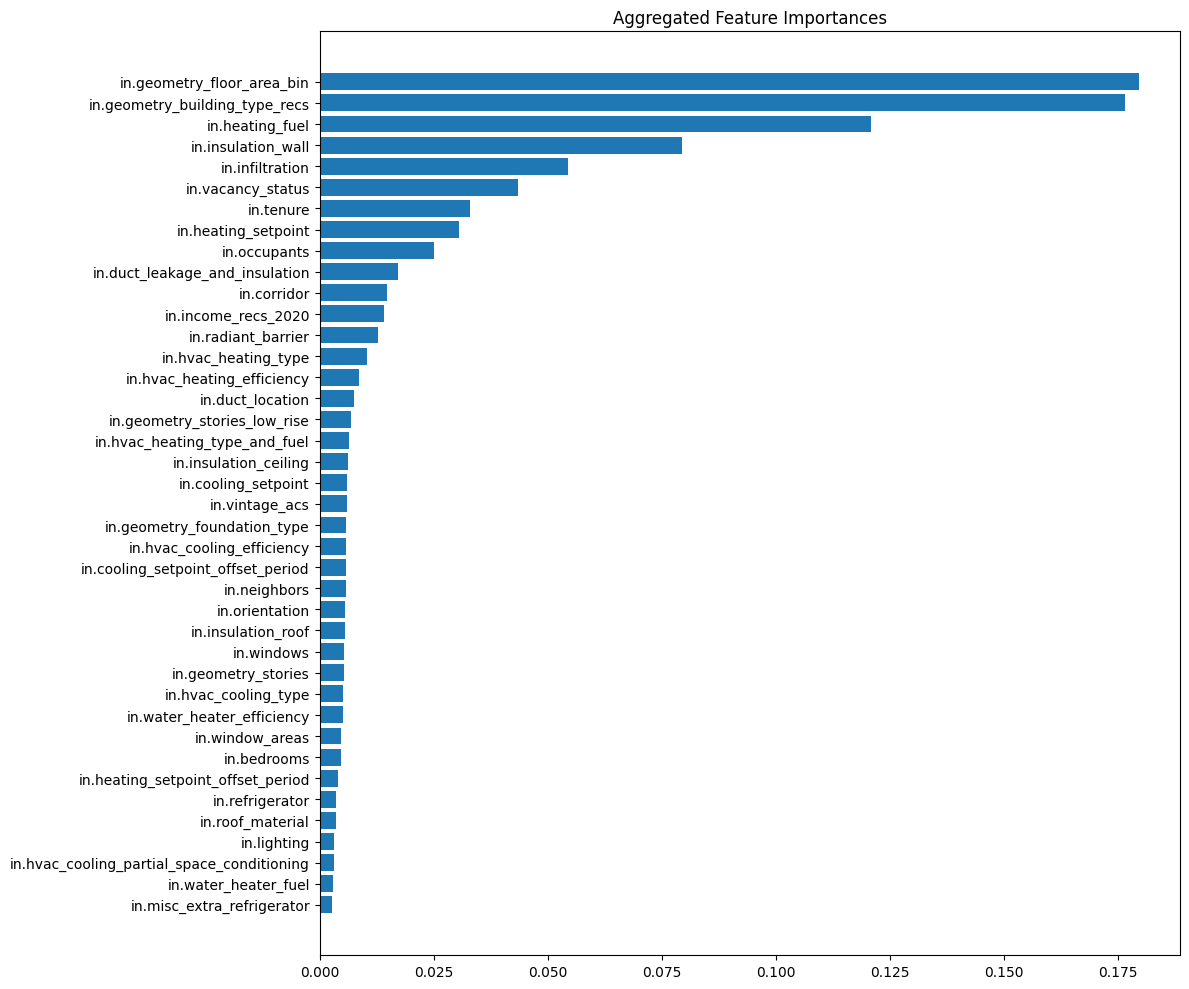

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import FunctionTransformer


def convert_to_string(X):
    return X.astype(str)


data = new_df

data = data.drop(columns=['in.sqft'])

X = data.drop(columns=['out.site_energy.total.energy_consumption.kwh'])
y = data['out.site_energy.total.energy_consumption.kwh'].astype(float)

categorical_cols = X.select_dtypes(include=['object', 'category']).columns

numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns

numerical_transformer = SimpleImputer(strategy='median')

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('to_string', FunctionTransformer(convert_to_string)),  # Convert all to string
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

model = RandomForestRegressor(n_estimators=100, random_state=0)

clf = Pipeline(steps=[('preprocessor', preprocessor),
                      ('model', model)])

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=0)

clf.fit(X_train, y_train)

ohe = (clf.named_steps['preprocessor']
         .named_transformers_['cat']
         .named_steps['onehot'])
feature_names = ohe.get_feature_names_out(input_features=categorical_cols)
feature_names = np.r_[numerical_cols, feature_names]

importances = clf.named_steps['model'].feature_importances_

original_feature_importances = dict(zip(numerical_cols, importances[:len(numerical_cols)]))

for i, feature in enumerate(feature_names[len(numerical_cols):]):
    
    original_name = '_'.join(feature.split('_')[:-1])
    if original_name not in original_feature_importances:
        original_feature_importances[original_name] = 0
    original_feature_importances[original_name] += importances[i + len(numerical_cols)]

sorted_features = sorted(original_feature_importances.items(), key=lambda x: x[1], reverse=True)


plt.figure(figsize=(12, 10))
plt.title("Aggregated Feature Importances")
N = 40

top_features = sorted_features[:N]
bars = plt.barh(range(N), [val for _, val in top_features])

plt.yticks(range(N), [key for key, _ in top_features], rotation=0)
plt.gca().invert_yaxis()  
plt.tight_layout()  
plt.show()




In [ ]:
## SAVE 
plt.figure(figsize=(12, 10))
plt.title("Aggregated Feature Importances")

N = 40

top_features = sorted_features[:N]
bars = plt.barh(range(N), [val for _, val in top_features])

plt.yticks(range(N), [key for key, _ in top_features], rotation=0)
plt.gca().invert_yaxis() 
plt.tight_layout()  
plt.savefig('RESULTS/feature_importances_plot.png')
plt.show()


sorted_features_df = pd.DataFrame(sorted_features, columns=['Feature', 'Importance'])
sorted_features_df.to_csv('RESULTS/sorted_feature_importances.csv', index=False)


# DEVELOPING A MODEL TO PREDICT

In [8]:
import pandas as pd

sorted_features_df = pd.read_csv('RESULTS/sorted_feature_importances.csv')

data_all_inputs = new_df

top_20_features = sorted_features_df['Feature'].head(20).tolist()

top_20_features.append('out.site_energy.total.energy_consumption.kwh')
top_20_features.insert(0,'bldg_id')

top_20_features.extend(['in.bedrooms','in.geometry_stories',\
                       'in.geometry_building_number_units_mf',\
                      'in.vintage_acs', 'in.hvac_cooling_type',\
                      'in.geometry_wall_type','in.roof_material',\
                    'in.geometry_garage','in.geometry_attic_type']) # add it for testing


selected_data = data_all_inputs[top_20_features]

selected_data.head()

# save the csv
#selected_data.to_csv('selected_data.csv')

,bldg_id,in.geometry_building_type_recs,in.geometry_floor_area_bin,in.heating_fuel,in.insulation_wall,in.infiltration,in.vacancy_status,in.tenure,in.geometry_floor_area,in.heating_setpoint,...,out.site_energy.total.energy_consumption.kwh,in.bedrooms,in.geometry_stories,in.geometry_building_number_units_mf,in.vintage_acs,in.hvac_cooling_type,in.geometry_wall_type,in.roof_material,in.geometry_garage,in.geometry_attic_type
0,9,Single-Family Detached,2500-3999,Natural Gas,"Wood Stud, R-15",8 ACH50,Occupied,Owner,2500-2999,70F,...,31523.017379,2,2,None,2000-09,Central AC,Wood Frame,"Asphalt Shingles, Medium",3 Car,Vented Attic
1,200,Multi-Family with 5+ Units,0-1499,Natural Gas,"Wood Stud, Uninsulated",20 ACH50,Occupied,Owner,1000-1499,65F,...,22301.536156,2,35,67,1960-79,Central AC,Steel Frame,"Asphalt Shingles, Medium",None,None
2,254,Single-Family Attached,0-1499,Natural Gas,"Wood Stud, R-11",15 ACH50,Occupied,Owner,1000-1499,70F,...,18223.159143,2,1,None,2010s,Central AC,Wood Frame,"Asphalt Shingles, Medium",None,Vented Attic
3,295,Single-Family Detached,1500-2499,Fuel Oil,"Wood Stud, Uninsulated",30 ACH50,Occupied,Owner,1500-1999,68F,...,49215.131743,3,2,None,<1940,Central AC,Wood Frame,"Asphalt Shingles, Medium",None,None
4,556,Single-Family Attached,1500-2499,Natural Gas,"Wood Stud, R-19",15 ACH50,Occupied,Owner,1500-1999,72F,...,18943.527834,3,2,None,1980-99,Central AC,Wood Frame,"Asphalt Shingles, Medium",None,Vented Attic


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors

df = selected_data

# Identify categorical variables
categorical_vars = df.select_dtypes(include=['object']).columns.tolist()

# Identify numeric variables
numeric_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# New buildings data known variables 
new_building = pd.DataFrame({'in.geometry_building_type_recs': ['Single-Family Detached'], 
                   'in.geometry_floor_area': ['2500-2999'], 
                   'in.heating_fuel': ['Natural Gas'],
                    'in.bedrooms':[3],
                    'in.geometry_stories': [3],
                    #'in.occupants':['3'],
                    #'out.site_energy.total.energy_consumption.kwh':[30000]
                             }, index=[0])


# Define the number of matches you want to find
n_matches = 40

relevant_columns = new_building.columns.tolist()
df_relevant = df[relevant_columns + ['bldg_id']]  # Include 'bldg_id' for identification


df_relevant_fixed = df_relevant.fillna('missing')
df_relevant_fixed[relevant_columns] = df_relevant_fixed[relevant_columns].astype(str)

new_building_fixed = new_building.fillna('missing')
new_building_fixed[relevant_columns] = new_building_fixed[relevant_columns].astype(str)

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('cat', categorical_transformer, relevant_columns)
])

df_relevant_transformed_fixed = preprocessor.fit_transform(df_relevant_fixed.drop(columns=['bldg_id']))
new_building_transformed_fixed = preprocessor.transform(new_building_fixed)

# NearestNeighbors to find the closest matches
neighbors = NearestNeighbors(n_neighbors=n_matches)
neighbors.fit(df_relevant_transformed_fixed)
distances_fixed, indices_fixed = neighbors.kneighbors(new_building_transformed_fixed)

for i, (new_building_indices, new_building_distances) in enumerate(zip(indices_fixed, distances_fixed)):
    print(f"New Building {i+1} Closest Matches:")
    for j, (match_index, distance) in enumerate(zip(new_building_indices, new_building_distances)):
        bldg_id = df_relevant_fixed.iloc[match_index]['bldg_id']
        print(f"  Match {j+1}: bldg_id {bldg_id} with distance {distance:.2f}")
    print()  


New Building 1 Closest Matches:
  Match 1: bldg_id 2198517 with distance 0.00
  Match 2: bldg_id 2134141 with distance 0.00
  Match 3: bldg_id 727443 with distance 0.00
  Match 4: bldg_id 2111493 with distance 0.00
  Match 5: bldg_id 384912 with distance 0.00
  Match 6: bldg_id 842153 with distance 0.00
  Match 7: bldg_id 1381703 with distance 0.00
  Match 8: bldg_id 2012515 with distance 0.00
  Match 9: bldg_id 969181 with distance 0.00
  Match 10: bldg_id 21858 with distance 1.41
  Match 11: bldg_id 64645 with distance 1.41
  Match 12: bldg_id 6284 with distance 1.41
  Match 13: bldg_id 130424 with distance 1.41
  Match 14: bldg_id 149659 with distance 1.41
  Match 15: bldg_id 24577 with distance 1.41
  Match 16: bldg_id 54147 with distance 1.41
  Match 17: bldg_id 142754 with distance 1.41
  Match 18: bldg_id 58002 with distance 1.41
  Match 19: bldg_id 65053 with distance 1.41
  Match 20: bldg_id 130501 with distance 1.41
  Match 21: bldg_id 47678 with distance 1.41
  Match 22: bld

In [6]:
# Initialize lists to store the new indices and their corresponding lowest distances
lowest_indices = []
lowest_distances = []
nearest_neighbor_bldgs = []

# Iterate over each set of distances for the new buildings
for i, distances in enumerate(distances_fixed):
    min_distance = np.min(distances)
    min_indices = np.where(distances == min_distance)[0]
    actual_indices = indices_fixed[i][min_indices]
    
    actual_distances = distances[min_indices]
    lowest_indices.append(actual_indices)
    lowest_distances.append(actual_distances)

    #Get building IDs for the nearest neighbors
    nearest_neighbor_ids = df_relevant_fixed.iloc[actual_indices]['bldg_id'].values
    nearest_neighbor_bldgs.append(nearest_neighbor_ids)

# Example of showing the closest matches for the first new building with their distances and building IDs
for idx, (dist, bldg_id) in enumerate(zip(lowest_distances[0], nearest_neighbor_bldgs[0])):
    print(f"Match {idx+1}: Building ID: {bldg_id}, Distance: {dist:.2f}")


Match 1: Building ID: 2198517, Distance: 0.00
Match 2: Building ID: 2134141, Distance: 0.00
Match 3: Building ID: 727443, Distance: 0.00
Match 4: Building ID: 2111493, Distance: 0.00
Match 5: Building ID: 384912, Distance: 0.00
Match 6: Building ID: 842153, Distance: 0.00
Match 7: Building ID: 1381703, Distance: 0.00
Match 8: Building ID: 2012515, Distance: 0.00
Match 9: Building ID: 969181, Distance: 0.00
